<a href="https://colab.research.google.com/github/Balachandar-Ganesan/DeepLearning/blob/main/009_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Slope: 0.9343
Y-Intercept: 0.4281


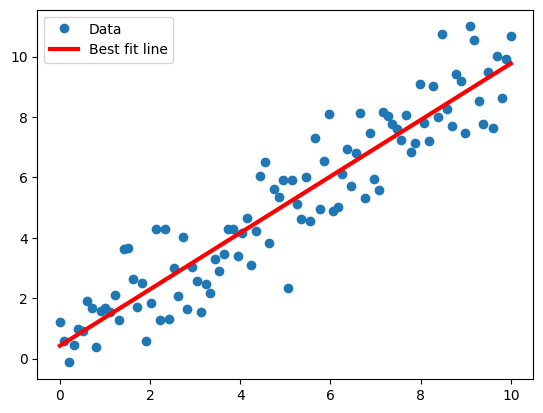

In [2]:
#Matrix Inverse Regression
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# 1. Create the data
x_vals = np.linspace(0, 10, 100)
y_vals = x_vals + np.random.normal(0, 1, 100)

# 2. Create design matrix (A) and target matrix (b)
x_vals_column = np.transpose(np.matrix(x_vals))
ones_column = np.transpose(np.matrix(np.repeat(1, 100)))
A = np.column_stack((x_vals_column, ones_column))
b = np.transpose(np.matrix(y_vals))

# 3. Create tensors (float32 for standard precision)
A_tensor = tf.cast(tf.constant(A), tf.float32)
b_tensor = tf.cast(tf.constant(b), tf.float32)

# 4. Matrix inverse solution: x = (AᵀA)⁻¹ * Aᵀb
# In TF 2.x, we use tf.linalg.inv for matrix inversion
tA_A = tf.matmul(tf.transpose(A_tensor), A_tensor)
tA_A_inv = tf.linalg.inv(tA_A)
product = tf.matmul(tA_A_inv, tf.transpose(A_tensor))
solution = tf.matmul(product, b_tensor)

# 5. Extract values directly (no sess.run required)
solution_eval = solution.numpy()
slope = solution_eval[0][0]
y_intercept = solution_eval[1][0]

print(f'Slope: {slope:.4f}')
print(f'Y-Intercept: {y_intercept:.4f}')

# 6. Plot results
best_fit = slope * x_vals + y_intercept
plt.plot(x_vals, y_vals, 'o', label='Data')
plt.plot(x_vals, best_fit, 'r-', label='Best fit line', linewidth=3)
plt.legend(loc='upper left')
plt.show()


slope: 0.9953183591663599
y_intercept: -0.05400448987554862


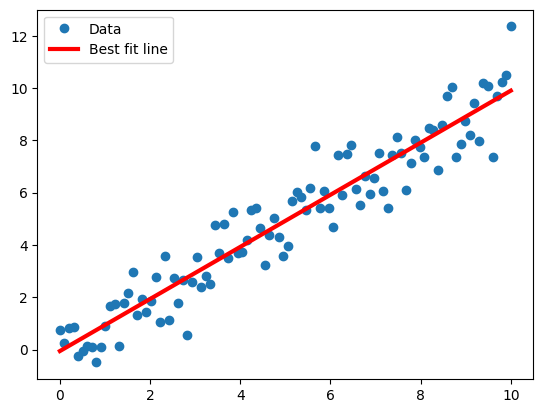

In [3]:
#Decomposition Method
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# 1. Create the data
x_vals = np.linspace(0, 10, 100)
y_vals = x_vals + np.random.normal(0, 1, 100)

# 2. Create design matrix (A) and target matrix (b)
x_vals_column = np.transpose(np.matrix(x_vals))
ones_column = np.transpose(np.matrix(np.repeat(1, 100)))
A = np.column_stack((x_vals_column, ones_column))
b = np.transpose(np.matrix(y_vals))

# 3. Create tensors (cast to float64 to match numpy's default)
A_tensor = tf.cast(tf.constant(A), tf.float64)
b_tensor = tf.cast(tf.constant(b), tf.float64)

# 4. Cholesky Decomposition
# tf.cholesky -> tf.linalg.cholesky
tA_A = tf.matmul(tf.transpose(A_tensor), A_tensor)
L = tf.linalg.cholesky(tA_A)

# 5. Solve L*y = t(A)*b
tA_b = tf.matmul(tf.transpose(A_tensor), b_tensor)
# tf.matrix_solve -> tf.linalg.triangular_solve (more efficient for Cholesky)
sol1 = tf.linalg.triangular_solve(L, tA_b, lower=True)

# 6. Solve L' * x = sol1
# Transpose of L is upper triangular
sol2 = tf.linalg.triangular_solve(tf.transpose(L), sol1, lower=False)

# 7. Extract coefficients (Eager execution returns values immediately)
solution_eval = sol2.numpy()
slope = solution_eval[0][0]
y_intercept = solution_eval[1][0]

print(f'slope: {slope}')
print(f'y_intercept: {y_intercept}')

# 8. Get best fit line and plot
best_fit = slope * x_vals + y_intercept

plt.plot(x_vals, y_vals, 'o', label='Data')
plt.plot(x_vals, best_fit, 'r-', label='Best fit line', linewidth=3)
plt.legend(loc='upper left')
plt.show()


Starting L1 Training...
L1 Step #25: A = [3.1577268], b = [0.809448]
L1 Step #50: A = [2.936526], b = [1.7574478]

Starting L2 Training...
L2 Step #25: A = [1.3319557], b = [3.9535265]
L2 Step #50: A = [1.0569338], b = [4.529507]


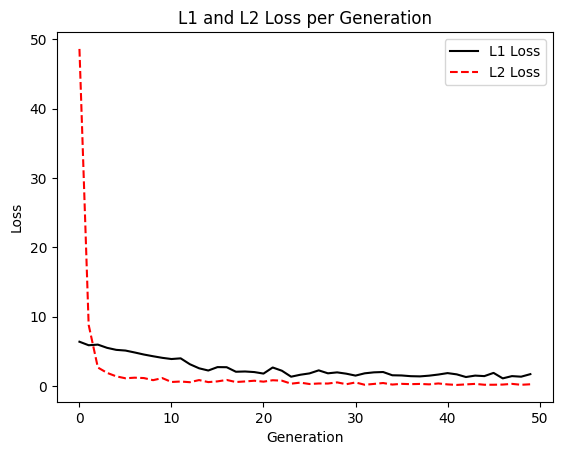

In [4]:
#L1 , L2... Absolute difference, Square of Difference
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn import datasets

# 1. Load the data
iris = datasets.load_iris()
x_vals = np.array([x[3] for x in iris.data], dtype=np.float32)
y_vals = np.array([y[0] for y in iris.data], dtype=np.float32)

# 2. Hyperparameters
batch_size = 25
learning_rate = 0.1 # Reduced from 0.4 for better stability
iterations = 50

# 3. Helper function for training (TF 2.x style)
def train_model(loss_type='l1'):
    # Variables for linear regression
    A = tf.Variable(tf.random.normal(shape=[1, 1]))
    b = tf.Variable(tf.random.normal(shape=[1, 1]))
    optimizer = tf.optimizers.SGD(learning_rate)
    loss_vec = []

    for i in range(iterations):
        # Create random batch
        rand_index = np.random.choice(len(x_vals), size=batch_size)
        rand_x = np.expand_dims(x_vals[rand_index], axis=1)
        rand_y = np.expand_dims(y_vals[rand_index], axis=1)

        with tf.GradientTape() as tape:
            # Model operations
            model_output = tf.add(tf.matmul(rand_x, A), b)

            # Loss functions
            if loss_type == 'l1':
                loss = tf.reduce_mean(tf.abs(rand_y - model_output))
            else: # L2
                loss = tf.reduce_mean(tf.square(rand_y - model_output))

        # Calculate gradients and update variables
        gradients = tape.gradient(loss, [A, b])
        optimizer.apply_gradients(zip(gradients, [A, b]))

        loss_vec.append(loss.numpy())

        if (i + 1) % 25 == 0:
            print(f'{loss_type.upper()} Step #{i+1}: A = {A.numpy()[0]}, b = {b.numpy()[0]}')

    return loss_vec

# 4. Execute training
print("Starting L1 Training...")
loss_vec_l1 = train_model(loss_type='l1')

print("\nStarting L2 Training...")
loss_vec_l2 = train_model(loss_type='l2')

# 5. Plot loss over time
plt.plot(loss_vec_l1, 'k-', label='L1 Loss')
plt.plot(loss_vec_l2, 'r--', label='L2 Loss')
plt.title('L1 and L2 Loss per Generation')
plt.xlabel('Generation')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()
